## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv("data/student_data.csv")

In [3]:
# Check missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [4]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
print("Categories in 'gender' variables: ", end=" ")
print(df["gender"].unique())
print()

print("Categories in 'race_ethnicity' variables: ", end=" ")
print(df["race_ethnicity"].unique())
print()

print("Categories in 'parental_level_of_education' variables: ", end=" ")
print(df["parental_level_of_education"].unique())
print()

print("Categories in 'lunch' variables: ", end=" ")
print(df["lunch"].unique())
print()

print("Categories in 'test_preparation_course' variables: ", end=" ")
print(df["test_preparation_course"].unique())

Categories in 'gender' variables:  <StringArray>
['female', 'male']
Length: 2, dtype: str

Categories in 'race_ethnicity' variables:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

Categories in 'parental_level_of_education' variables:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

Categories in 'lunch' variables:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

Categories in 'test_preparation_course' variables:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [10]:
numeric_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(include=['category','str']).columns.tolist()

print(
    f"{len(numeric_features)} number of numerical features and those features are {numeric_features}"
)
print()
print(
    f"{len(categorical_features)} number of categorical features and those features are {categorical_features}"
)

3 number of numerical features and those features are ['math_score', 'reading_score', 'writing_score']

5 number of categorical features and those features are ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [11]:
# Adding columns for Total Score and Average
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average"] = df["total_score"] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
reading_full = df[df["reading_score"] == 100]["average"].count()
writing_full = df[df["writing_score"] == 100]["average"].count()
math_full = df[df["math_score"] == 100]["average"].count()

print(f"There are {reading_full} number of student who got full marks in Reading")
print(f"There are {writing_full} number of student who got full marks in Writing")
print(f"There are {math_full} number of student who got full marks in Math")

There are 17 number of student who got full marks in Reading
There are 14 number of student who got full marks in Writing
There are 7 number of student who got full marks in Math


In [13]:
reading_less_20 = df[df["reading_score"] <= 20]["average"].count()
writing_less_20 = df[df["writing_score"] <= 20]["average"].count()
math_less_20 = df[df["math_score"] <= 20]["average"].count()

print(
    f"There are {reading_less_20} number of student who got less than 20 marks in Reading"
)
print(
    f"There are {writing_less_20} number of student who got less than 20 marks in Writing"
)
print(
    f"There are {math_less_20} number of student who got less than 20 marks in Math"
)

There are 1 number of student who got less than 20 marks in Reading
There are 3 number of student who got less than 20 marks in Writing
There are 4 number of student who got less than 20 marks in Math


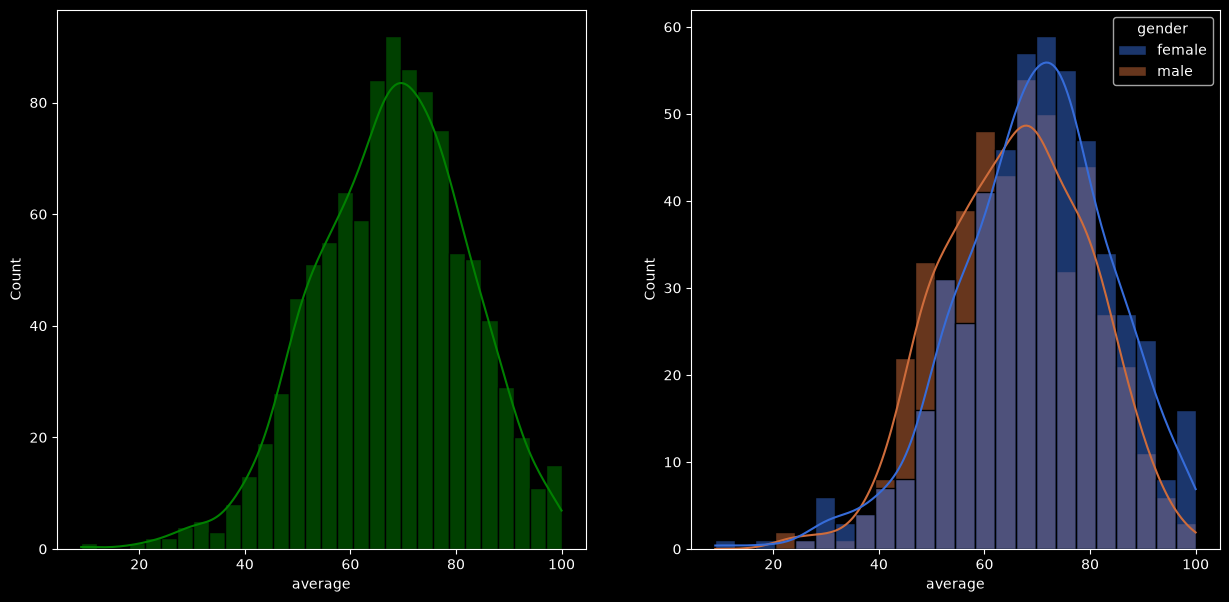

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x="average", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df, x="average", kde=True, hue="gender")
plt.show()

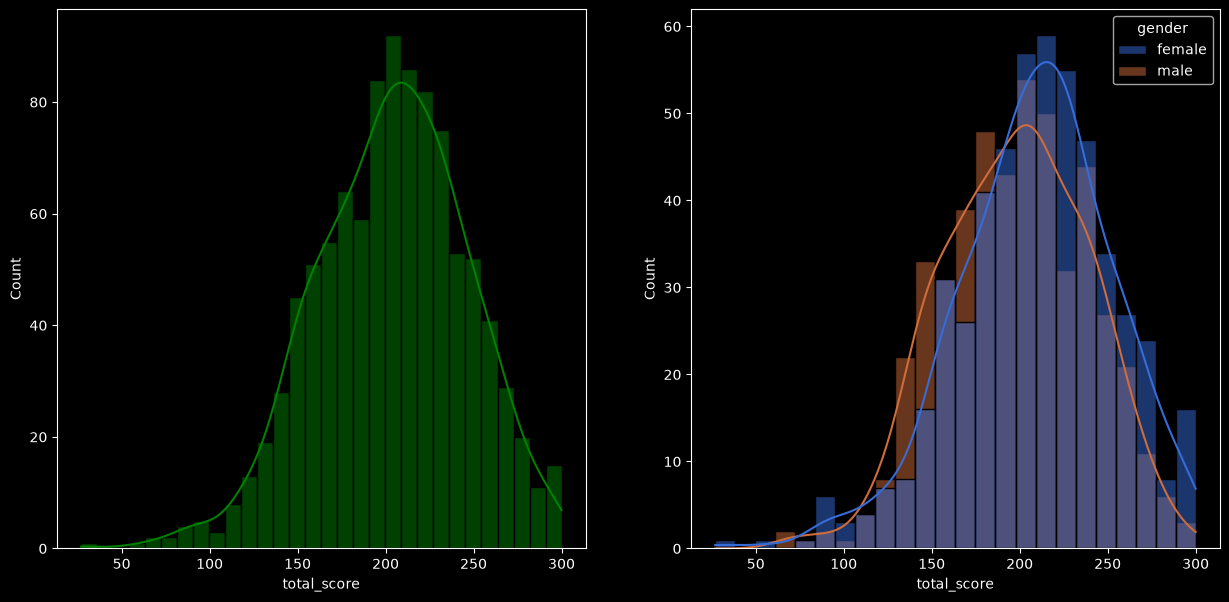

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x="total_score", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df, x="total_score", kde=True, hue="gender")
plt.show()

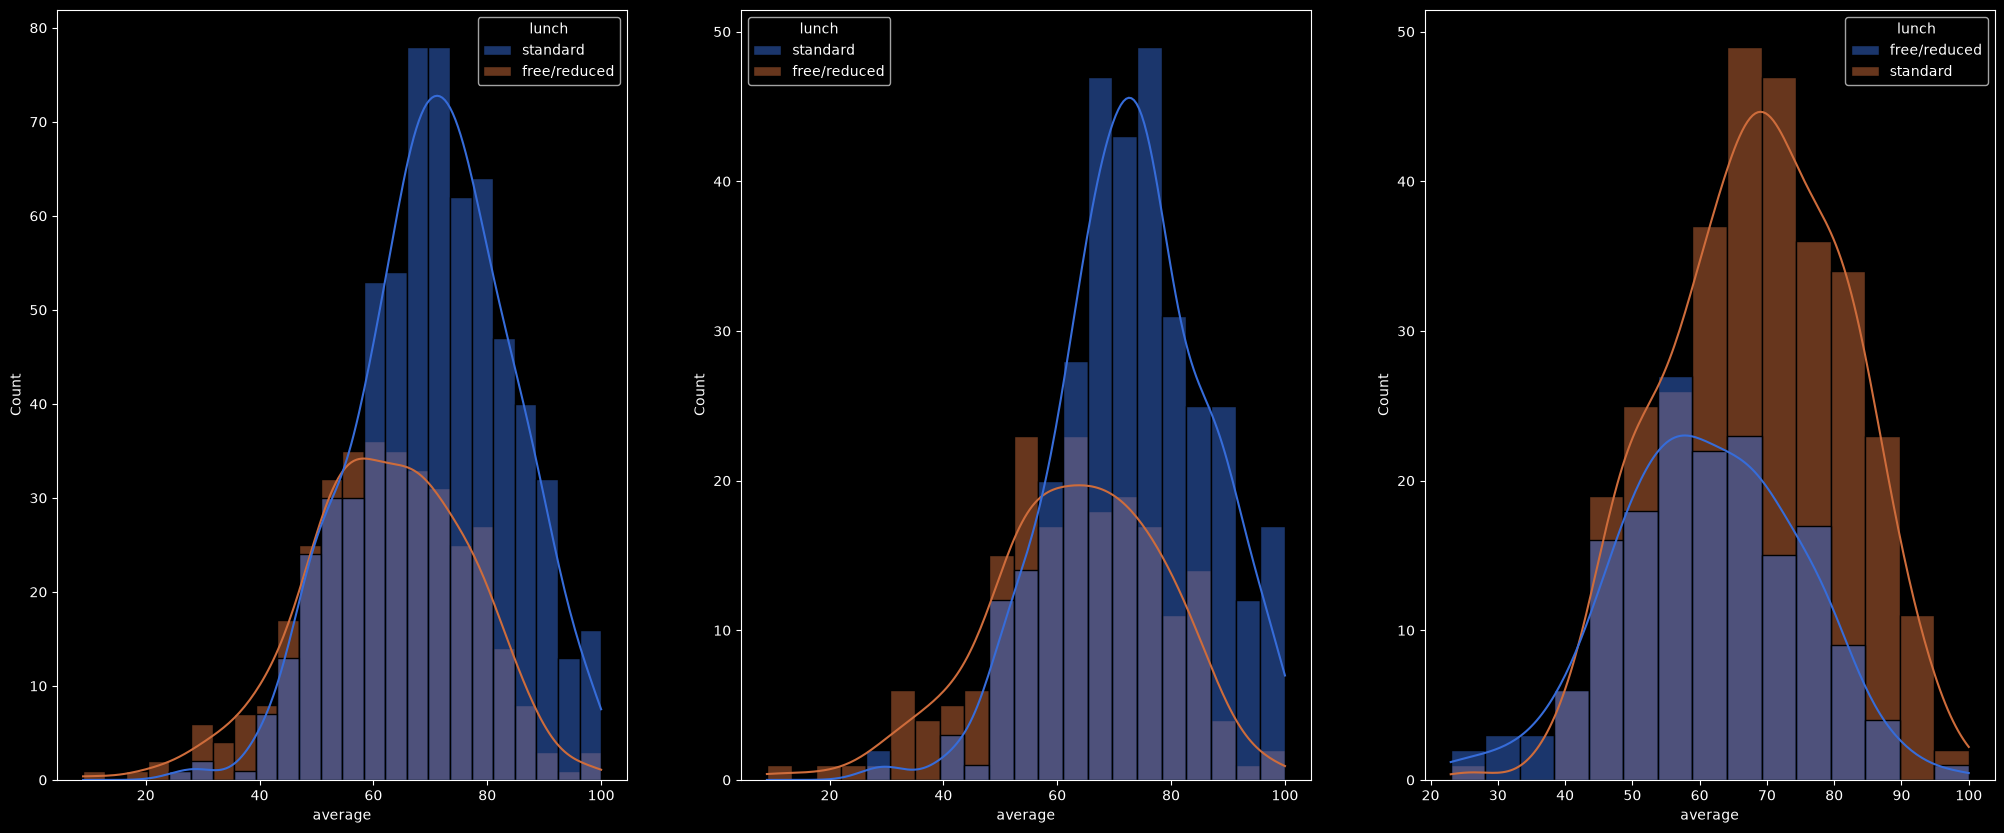

In [16]:
plt.subplots(1, 3, figsize=(25, 10))
plt.subplot(131)
sns.histplot(df, x="average", kde=True, hue="lunch")
plt.subplot(132)
sns.histplot(df[df["gender"] == "female"], x="average", kde=True, hue="lunch")
plt.subplot(133)
sns.histplot(df[df["gender"] == "male"], x="average", kde=True, hue="lunch")
plt.show()

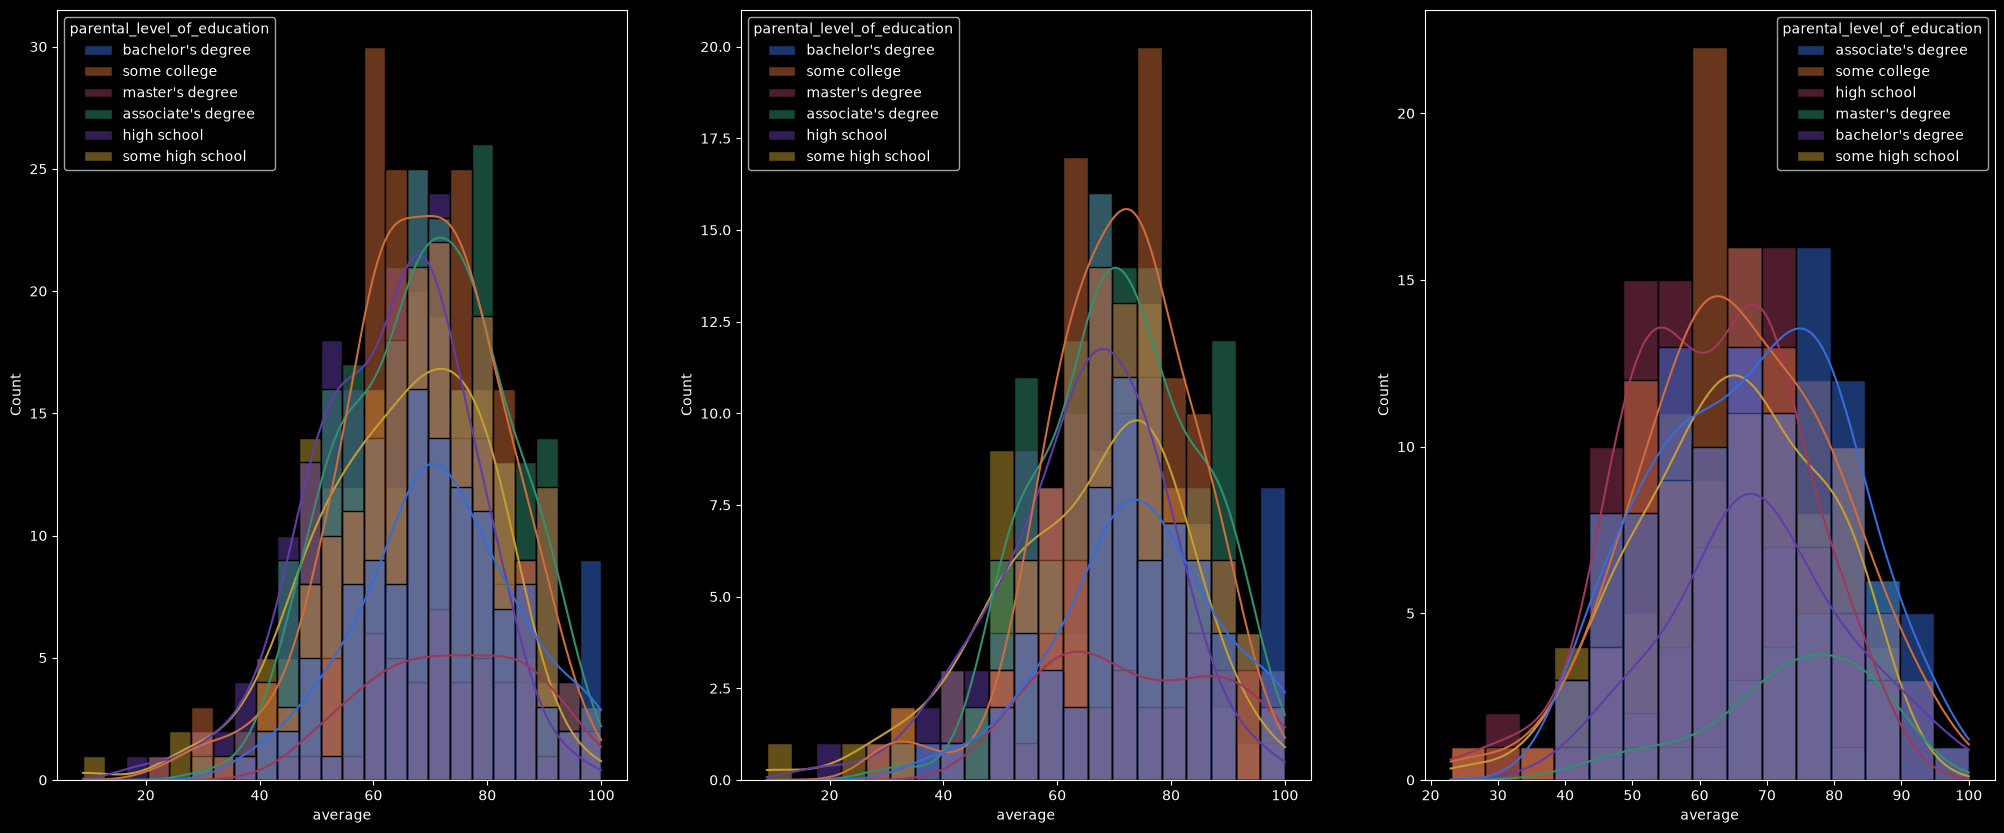

In [17]:
plt.subplots(1, 3, figsize=(25, 10))
plt.subplot(131)
sns.histplot(df, x="average", kde=True, hue="parental_level_of_education")
plt.subplot(132)
sns.histplot(df[df["gender"] == "female"], x="average", kde=True, hue="parental_level_of_education")
plt.subplot(133)
sns.histplot(df[df["gender"] == "male"], x="average", kde=True, hue="parental_level_of_education")
plt.show()

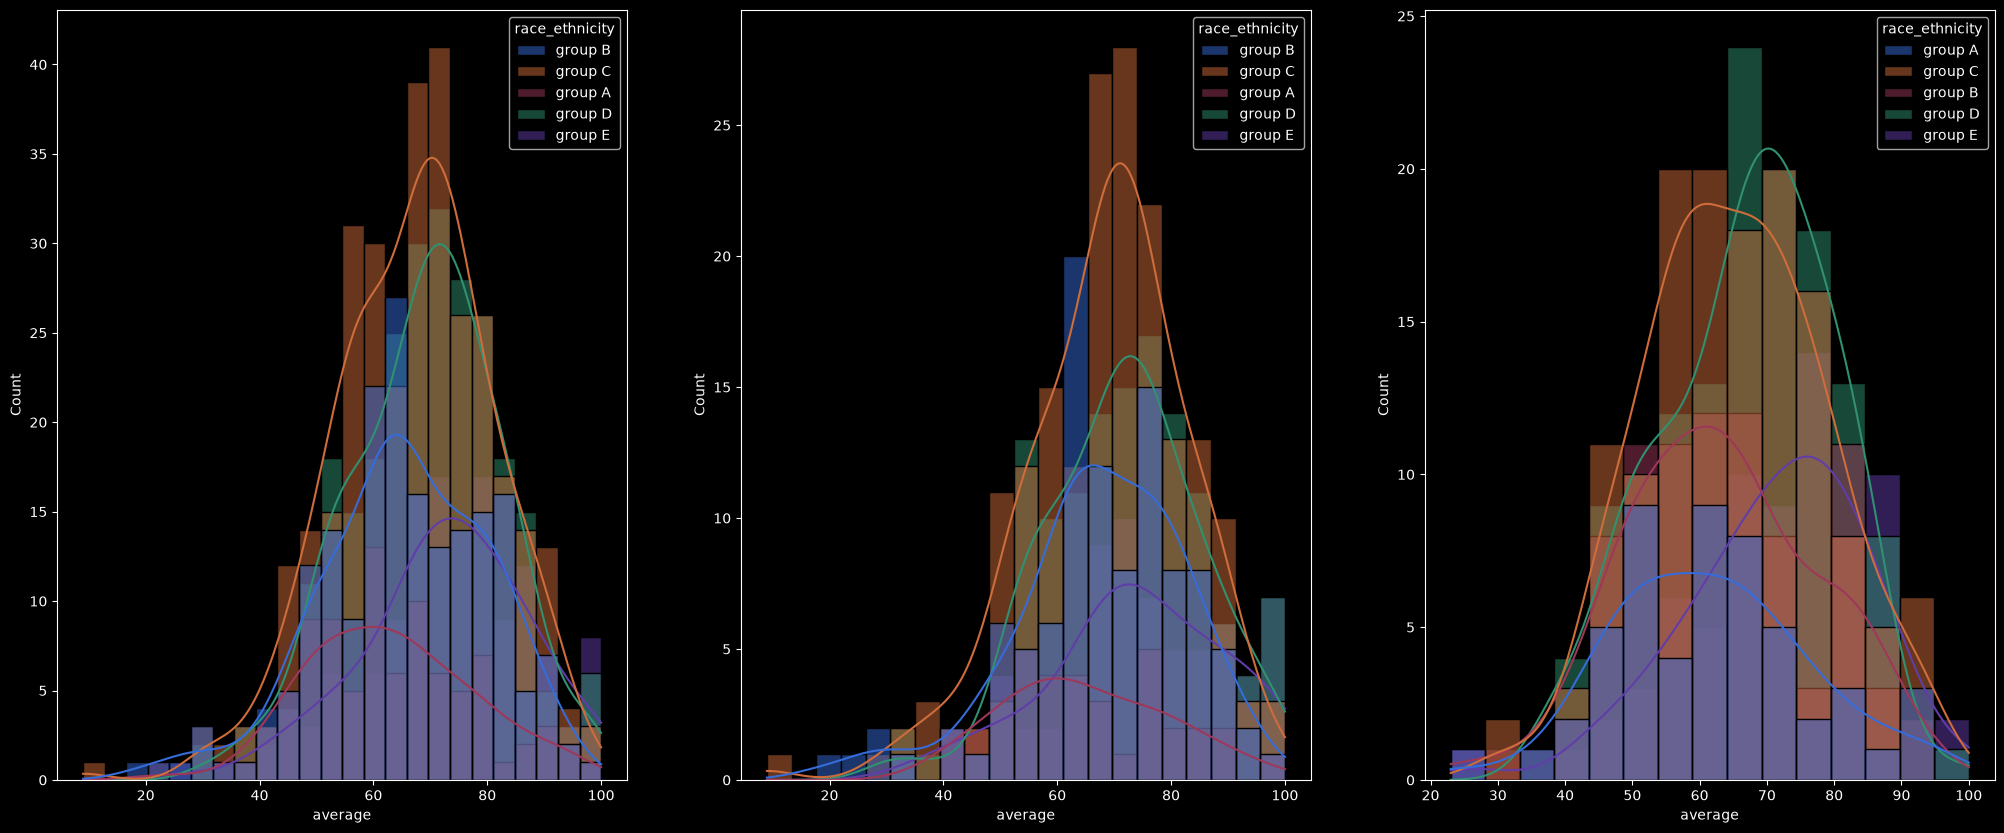

In [18]:
plt.subplots(1, 3, figsize=(25, 10))
plt.subplot(131)
sns.histplot(df, x="average", kde=True, hue="race_ethnicity")
plt.subplot(132)
sns.histplot(df[df["gender"] == "female"], x="average", kde=True, hue="race_ethnicity")
plt.subplot(133)
sns.histplot(df[df["gender"] == "male"], x="average", kde=True, hue="race_ethnicity")
plt.show()

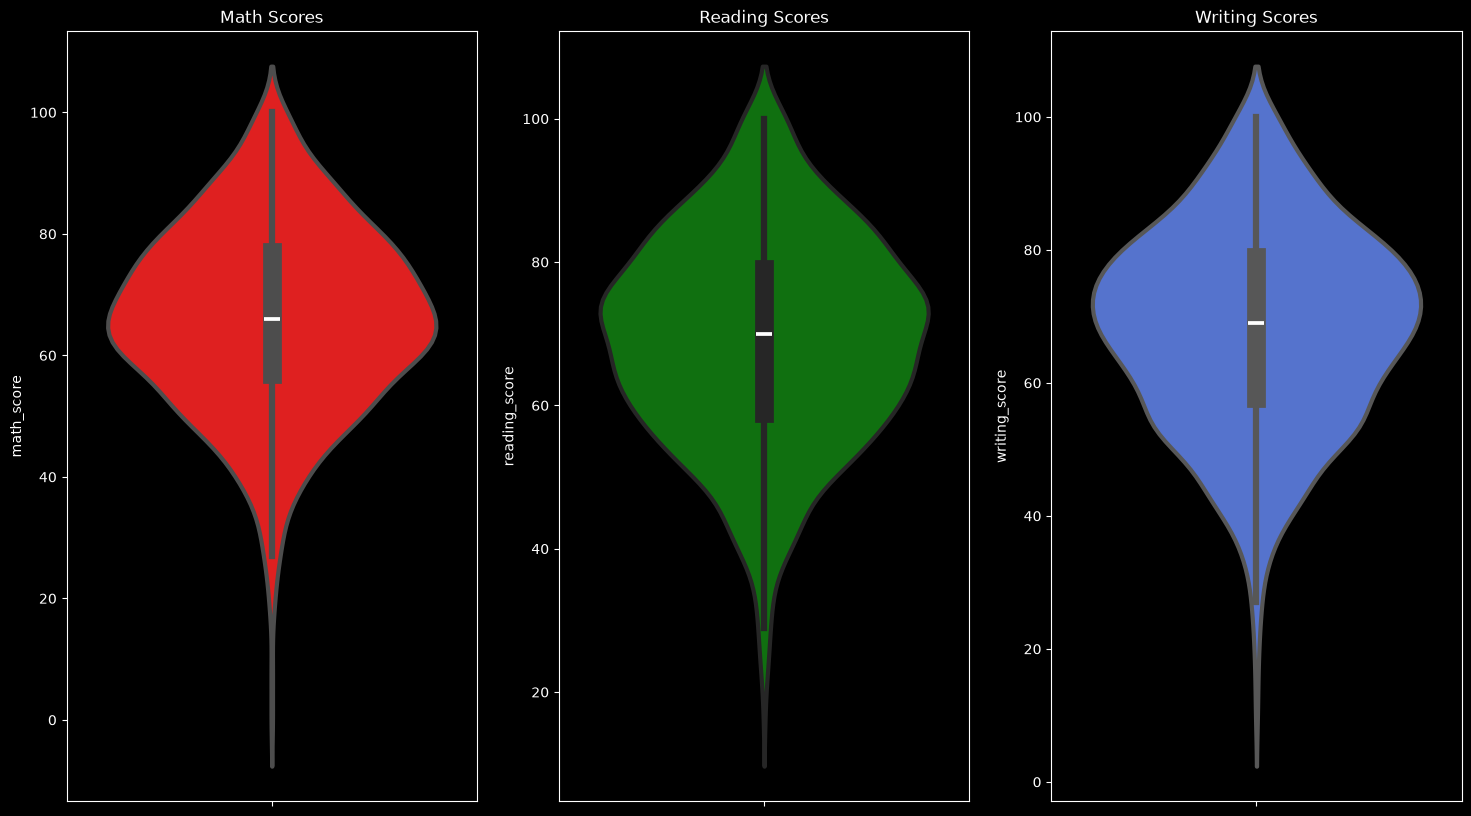

In [19]:
plt.figure(figsize=(18, 10))

plt.subplot(1, 3, 1)
plt.title("Math Scores")
sns.violinplot(y=df["math_score"], color="r", linewidth=3)

plt.subplot(1, 3, 2)
plt.title("Reading Scores")
sns.violinplot(y=df["reading_score"], color="g", linewidth=3)

plt.subplot(1, 3, 3)
plt.title("Writing Scores")
sns.violinplot(y=df["writing_score"], color="royalblue", linewidth=3)
plt.show()

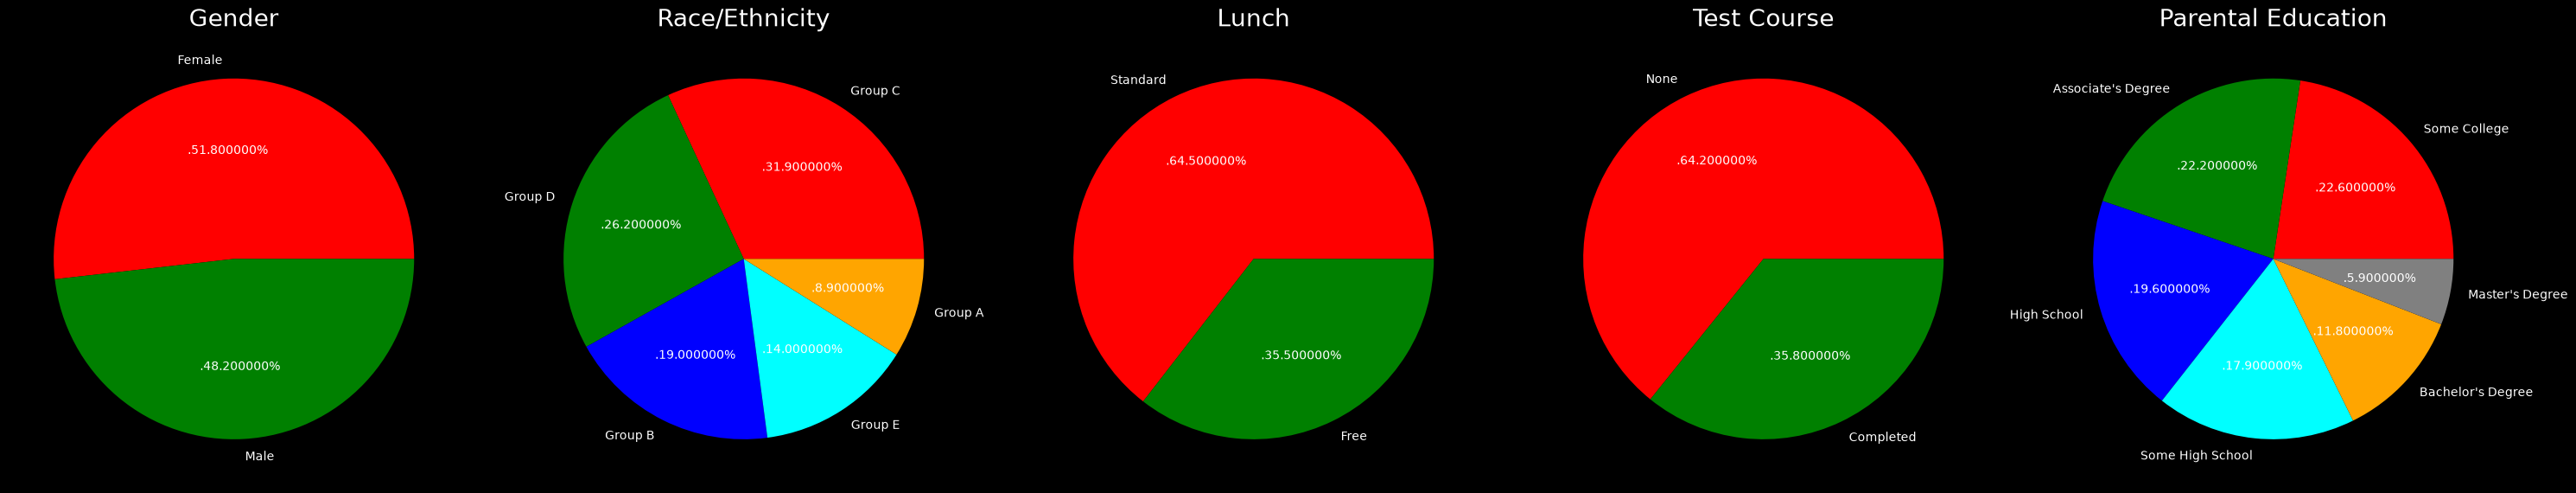

In [20]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

In [21]:
df.to_csv('data/student_data_train.csv', index = False)